In [13]:
# Data manipulation and analysis libraries
import pandas as pd
pd.set_option('display.max_columns', None)  # Ensure all columns are visible when displaying DataFrames

# Numerical computing library
import numpy as np

# Data visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Environment and warning management
import warnings
warnings.filterwarnings('ignore')  # Suppress clean-up or deprecation warnings to keep the output clean

In [14]:
# Load the cleaned and merged dataset for statistical analysis and visualization
df_clean = pd.read_csv("../data/Customer_Flight_Loyalty_Clean.csv")

In [15]:
df_clean.sample(5)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Customer Active
87622,294283,2017,6,17,1,18,4032,403.0,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,93197.000000,Married,Star,2585.96,Standard,2014,1,True
328310,569880,2018,8,3,3,6,4254,425.0,Canada,British Columbia,Vancouver,V1E 4R6,Male,Bachelor,67044.000000,Married,Star,7706.04,Standard,2012,9,True
52450,210385,2017,4,0,0,0,0,0.0,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,89345.000000,Divorced,Star,3209.66,2018 Promotion,2018,3,True
28163,708343,2017,2,0,0,0,0,0.0,Canada,Newfoundland,St. John's,A1C 6H9,Female,Bachelor,91763.000000,Married,Star,2719.26,Standard,2014,10,True
283384,863744,2018,5,2,1,3,3597,359.0,Canada,Quebec,Montreal,H2Y 4R4,Female,College,80265.731496,Single,Nova,8672.81,Standard,2013,5,True


## 01. Visualisation

### 1. How is the number of flights booked distributed across the months of the year?


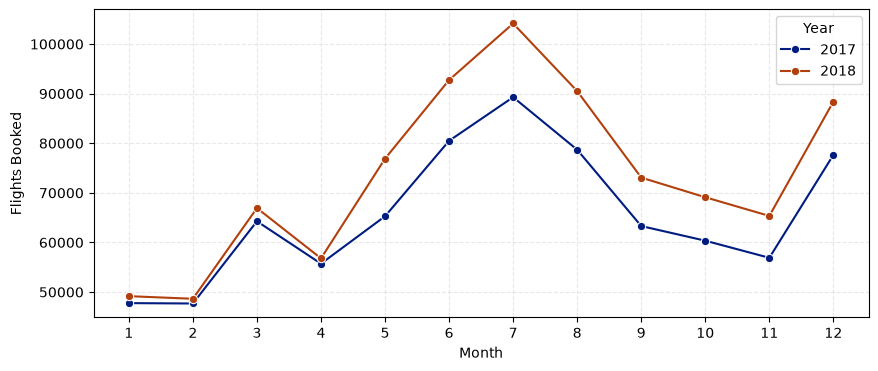

In [16]:
# Data aggregation by month and year
flights_per_month = df_clean.groupby(['Year', 'Month'], as_index=False)['Flights Booked'].sum()

# Line plot configuration
plt.figure(figsize=(10, 4))
ax = sns.lineplot(
    data=flights_per_month, 
    x='Month', 
    y='Flights Booked', 
    hue='Year',          # Separate the data into individual lines per year
    marker='o', 
    palette='dark'       # Uses a clean color palette for differentiation
)

# Force all 12 months to display on the X-axis
plt.xticks(ticks=range(1, 13))
plt.grid(True, linestyle='--', alpha=0.5, color='lightgray')

plt.savefig("../figures/03_Visualisation_figures/Flight_per_Month.png", dpi=300)

**Insight:** As shown in image, a lower volume of flights is observed during January, February, April, and November. Conversely, there is a significant increase during the summer months (peaking in July) and in December, which is highly consistent with standard holiday and seasonal vacation periods. This seasonal pattern remains remarkably consistent across both analyzed years.

### 2. Is there a relationship between flight distance and the points accumulated by customers?


Spearman correlation between Distance and Points Accumulated: 0.9980


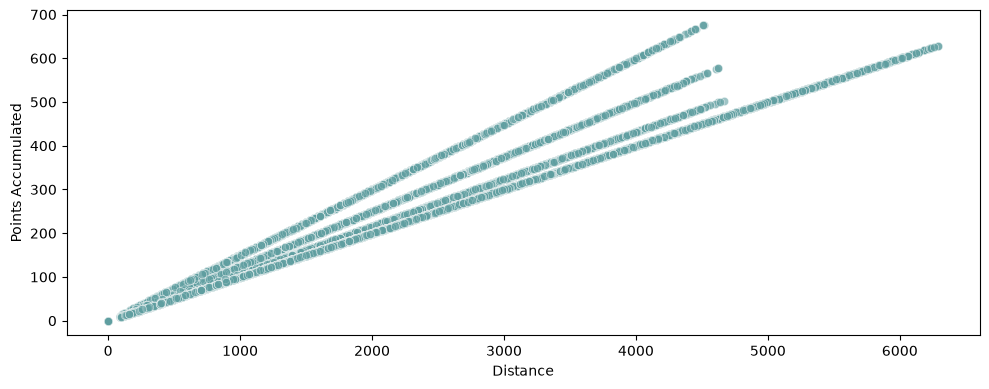

In [17]:
# Calculate the correlation number
correlation_D_PA = df_clean['Distance'].corr(df_clean['Points Accumulated'], method='spearman')
print (f"Spearman correlation between Distance and Points Accumulated: {correlation_D_PA:.4f}")

# Create a figure for the key correlation insights
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))

# Scatter plot for Distance vs Points Accumulated
sns.scatterplot(
    data=df_clean, 
    x='Distance', 
    y='Points Accumulated', 
    ax=axes, 
    color='cadetblue', 
    alpha=0.6
)


plt.tight_layout()
plt.savefig("../figures/03_Visualisation_figures/Distance_Points_Correlation.png", dpi=300)

**Insight:** The correlation between distance and accumulated points is practically **1**, indicating that both metrics are directly proportional to each other. This aligns perfectly with industry standards, as loyalty program points typically accumulate based directly on the number of miles flown.

### 3. What is the distribution of customers by province or state?


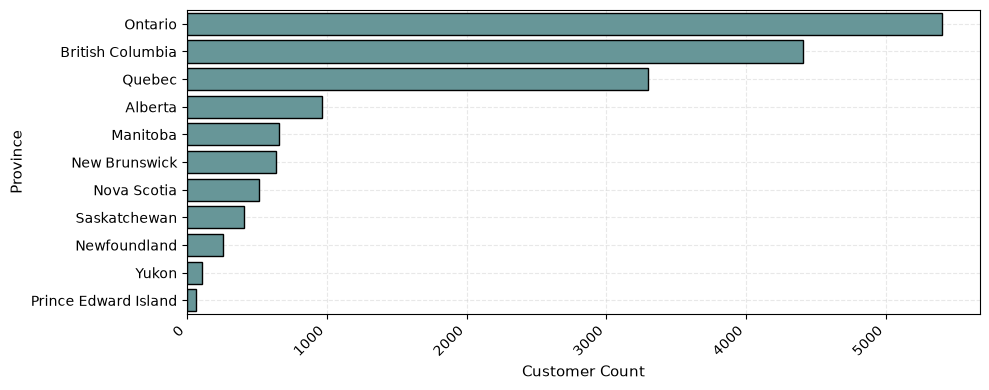

In [18]:
# Filter unique customers to avoid transactional duplication
df_unique_customers = df_clean.drop_duplicates(subset='Loyalty Number')

# Plot configuration
plt.figure(figsize=(10, 4))
ax = sns.countplot(
    data=df_unique_customers,
    y='Province',
    color='cadetblue',
    edgecolor='black',
    orient= 'h',
    linewidth=1,
    order=df_unique_customers['Province'].value_counts().index
)

# Component styling and grid integration
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5, color='lightgray', zorder=0)
plt.gca().set_axisbelow(True)

# Axis labels and layout optimization
plt.ylabel('Province', fontsize=11)
plt.xlabel('Customer Count', fontsize=11)
plt.tight_layout()

plt.savefig("../figures/03_Visualisation_figures/Customer_distribution_per_Province.png", dpi=300)

**Insight:** It can be observed that the highest number of customers come from **Ontario**, **British Columbia**, and **Quebec**, three of Canada's major and highly populated coastal or water-accessible provinces.

### 4. How does the average salary compare across different customer education levels?

In [19]:

df_unique_customers.groupby('Education')['Salary'].count()

Education
Bachelor                10475
College                  4238
Doctor                    734
High School or Below      782
Master                    508
Name: Salary, dtype: int64

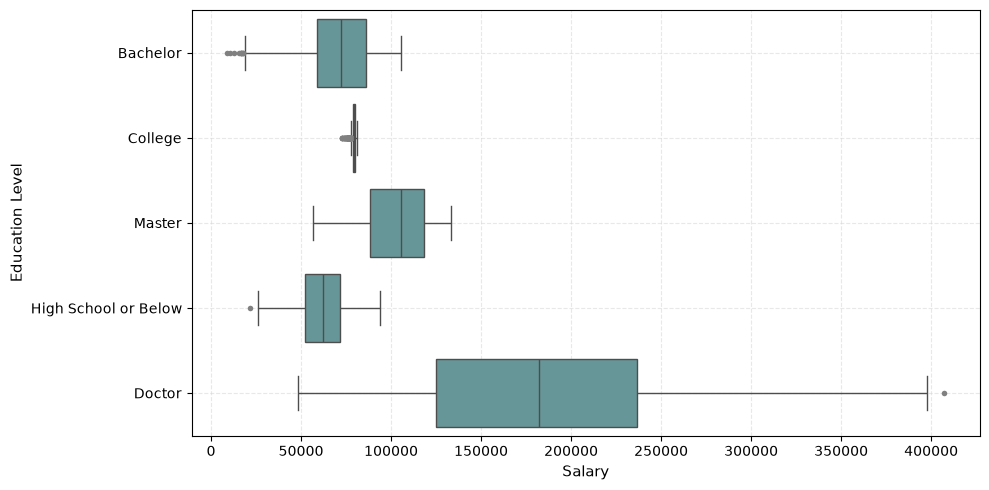

In [20]:
# Plot salary distribution by education level using a boxplot
plt.figure(figsize=(10, 5))
ax = sns.boxplot(
    data=df_unique_customers,
    y='Education',
    x='Salary',
    color='cadetblue',
    linewidth=1,
    flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'markersize': 4, 'markeredgecolor': 'none'}
)

# Component styling and grid integration
plt.grid(True, linestyle='--', alpha=0.5, color='lightgray', zorder=0)
plt.gca().set_axisbelow(True)

# Axis labels and layout optimization
plt.ylabel('Education Level', fontsize=11)
plt.xlabel('Salary', fontsize=11) 
plt.tight_layout()

plt.savefig("../figures/03_Visualisation_figures/Blx_Salary_Education.png", dpi=300)

**Insight:** A direct correlation is observed between education level and salary distribution. Customers with a **High School or Below** education level fall within the lowest income bracket, whereas those holding a **Doctorate** sit at the top of the earnings scale. Furthermore, the **College** and **Bachelor** segments show a heavy concentration of data points within the overall median range, reflecting the fact that these two profiles represent the vast majority of the customer base.

### 5. What is the proportion of customers by loyalty card type?

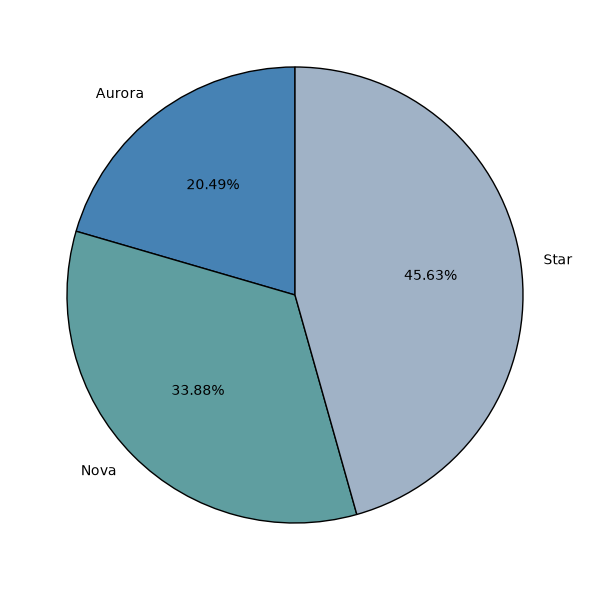

In [25]:
# Aggregate unique customers per loyalty card tier
loyalty_card_customers = df_unique_customers.groupby('Loyalty Card')['Loyalty Number'].count()

# Define a cohesive color palette matching the project identity
custom_colors = ['#4682B4', 'cadetblue', '#A0B2C6'] 

# Plot configuration for the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    loyalty_card_customers.values, 
    labels=loyalty_card_customers.index, 
    autopct='%1.2f%%',       # Formats the labels to show percentages with two decimals
    startangle=90,          # Rotates the start of the pie chart for better layout orientation
    colors=custom_colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True} # Clean black borders
)

# Layout optimization
plt.tight_layout() 

plt.savefig("../figures/03_Visualisation_figures/Pie_Loyalty_Card_proportion.png", dpi=300)

**Insight:** The distribution reveals that nearly half of the customer base holds the entry-level membership tier. Conversely, the premium, high-value loyalty card categories are inherently concentrated among a significantly smaller and more exclusive segment of customers.

### 6. How are customers distributed by marital status and gender?

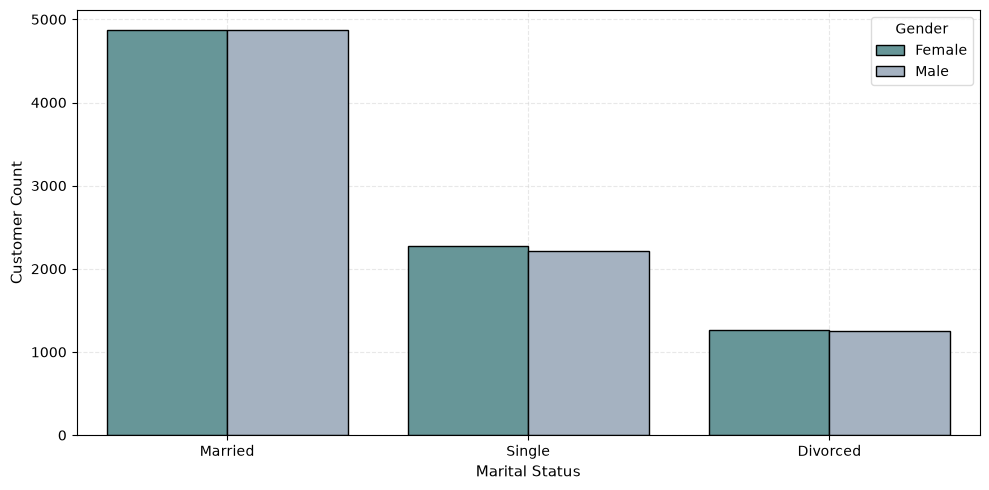

In [22]:
# Plot customer distribution by marital status and gender
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=df_unique_customers,
    x='Marital Status',
    hue='Gender',
    palette=['cadetblue', '#A0B2C6'],
    edgecolor='black',
    linewidth=1
)

# Component styling and grid integration
plt.grid(True, linestyle='--', alpha=0.5, color='lightgray', zorder=0)
plt.gca().set_axisbelow(True)

# Axis labels and layout optimization
plt.xlabel('Marital Status', fontsize=11)
plt.ylabel('Customer Count', fontsize=11)
plt.legend(title='Gender', frameon=True, facecolor='white', edgecolor='lightgray')
plt.tight_layout()

plt.savefig("../figures/03_Visualisation_figures/Gender_vs_Marital_Status.png", dpi=300)

**Insight:** The data reveals a highly uniform and symmetrical distribution between gender and marital status. The proportion of male and female customers remains remarkably consistent across all categories, indicating that gender does not influence the demographic behavior regarding marital status within the customer base.

## 02. Flight Booking Differences by Education Level

In [23]:
df_phase4 = df_clean[['Education', 'Flights Booked']]

df_phase4.groupby('Education')['Flights Booked'].agg(['mean', 'std'])

,mean,std
Education,,
Bachelor,4.110288,5.221671
College,4.169744,5.246040
Doctor,4.175512,5.256971
High School or Below,4.176209,5.239267
Master,4.200700,5.213956


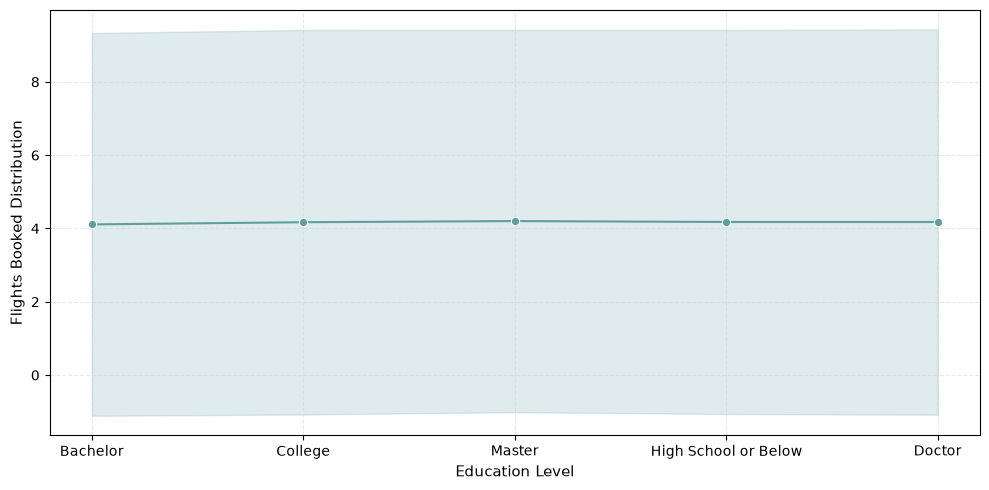

In [24]:
# Plot line trend of average flights booked with standard deviation shading
plt.figure(figsize=(10, 5))
ax = sns.lineplot(
    data=df_clean,
    x='Education',
    y='Flights Booked',
    color='cadetblue',
    marker='o',
    errorbar='sd'                # Shaded area represents the standard deviation range
)

# Component styling and grid integration
plt.grid(True, linestyle='--', alpha=0.5, color='lightgray')

# Axis labels and layout optimization
plt.xlabel('Education Level', fontsize=11)
plt.ylabel('Flights Booked Distribution', fontsize=11)
plt.tight_layout()

**Insight:** Both the visualization and the calculated summary statistics demonstrate that the mean and standard deviation (STD) values remain practically identical across all education levels. This leads to the clear conclusion that the level of education does not influence the number of flight bookings.